# Numerical Simulation Laboratory - Exercise 09

## INTRODUCTION

### The Traveling Salesman Problem


The Traveling Salesman Problem (TSP) is the problem of finding the shortest closed path that visits each city exactly once and then returns to the starting city.

Given a set of $N$ cities with positions $\vec{c}_i$, a possible path can be represented as a permutation of the city labels. In this exercise the 1D representation is used: an individual of the genetic algorithm is a vector of integers, where each integer identifies a city and the order of the vector gives the visiting order.

For example, for $N=5$ cities, the vector

$$
[1,3,5,4,2]
$$

represents the path

$$
\vec{c}_1 \rightarrow \vec{c}_3 \rightarrow \vec{c}_5 \rightarrow \vec{c}_4 \rightarrow \vec{c}_2 \rightarrow \vec{c}_1 .
$$

The quality of a path is measured through the cost function

$$
L^{(1)} = \sum_{i=1}^{N} |\vec{x}_i-\vec{x}_{i+1}|,
$$

with $\vec{x}_{N+1}=\vec{x}_1$ in order to close the tour.

The goal of the exercise is to find the best possible path by minimizing this cost function.

### Genetic algorithms

#### Idea and biological inspiration

Genetic Algorithms (GAs) were introduced by John Holland in the 1960s and developed in the following decade as a formal abstraction of natural adaptation. The basic idea is to use simple mechanisms inspired by biological evolution to solve optimization problems.

The analogy is the following: in biology, evolution explores a huge space of possible genetic sequences and favours organisms that are better adapted to their environment. In optimization, a GA explores a huge space of possible candidate solutions and favours those with better fitness. This is useful especially when the search space is too large to be explored exhaustively, and when there are no known deterministic alternatives that can efficiently find a good solution with reliable convergence properties.

The evolutionary rules are simple: random variation is produced through mutation, recombination/crossover and similar operators, while selection gives fitter individuals a higher probability of reproducing.

This makes genetic algorithms an example of a **metaheuristic method**: a metaheuristic is a general optimization strategy that combines problem-independent search rules with stochastic choices, instead of following an exact deterministic recipe for constructing the solution.

Genetic algorithms do not require derivatives or detailed analytical information about the function to optimize: they only need a rule to evaluate the quality of each candidate solution.

In particular, metaheuristic methods combine two important ingredients:

- **diversification**, because mutations and recombinations explore new regions of the search space;
- **intensification**, because selection concentrates the search around good candidate solutions.

Genetic algorithms are also **intrinsically parallelizable**. Many optimization problems require searching through a huge number of possible solutions, and this search can benefit from exploring many different candidates at the same time. A GA naturally does this because it evolves an entire population of individuals, rather than following a single trajectory in the search space.

#### Population, chromosomes, genes and alleles

A genetic algorithm works with a **population** of candidate solutions. Each candidate solution is called an **individual** or **chromosome**.

In the simplest case, chromosomes can be represented as finite-length **bit strings**, for example

$$
[1,0,0,1,1,0,1].
$$

More generally, other alphabets and representations can also be used, depending on the problem.

The elements of a chromosome are called **genes**, while the possible values that a gene can assume are called **alleles**. In a binary representation, for example, each bit is a gene and the possible alleles are only $0$ and $1$.

In the present exercise the chromosome is not a binary string, but a **permutation of city labels**. Each gene corresponds to a position in the path, and its allele is the label of the city visited at that position. Therefore, each chromosome represents one possible path of the salesman.

#### Genetic algorithm workflow

A simple genetic algorithm can be summarized as follows:

1. generate an initial population of candidate solutions;
2. evaluate the cost function associated with each individual;
3. select parent individuals, giving higher probability to better individuals;
4. produce offspring through crossover;
5. apply random mutations to the offspring;
6. replace the old population with the new one;
7. repeat the procedure for many generations.

Each iteration of this process is called a **generation**, while the complete sequence of generations is called a **run**.

In general, the **fitness** is a measure of how good an individual is. In a maximization problem, higher fitness means a better individual. In the present TSP minimization problem, the quality is measured through the path length $L^{(1)}$: shorter paths are better, so the population is ordered according to increasing cost.

The role of the genetic algorithm is therefore to make shorter paths more likely to survive and reproduce, while still keeping enough randomness to explore new possible tours.

#### Genetic operators

The simplest genetic algorithms are based on three fundamental operators: **selection**, **crossover** and **mutation**.

The **selection** operator chooses which individuals are allowed to reproduce. Better individuals should have a higher probability of being selected, so that their "genetic information" is more likely to be transmitted to the next generation. Selection is responsible for the **intensification** of the search around promising regions of the solution space.

The **crossover** operator combines two parent chromosomes to generate new offspring. In the standard binary case, this can be done by cutting two strings at a randomly chosen position and exchanging the corresponding parts. In the TSP, crossover must be adapted carefully, because the offspring must still be valid permutations of the cities. Crossover contributes to **diversification**, because it generates new combinations of genetic material already present in the population.

The **mutation** operator randomly modifies an individual. In binary genetic algorithms this can correspond to flipping one or more bits. In the TSP, mutations can instead be implemented as operations on the order of the cities, such as swapping two cities, shifting part of the path, exchanging blocks, or reversing a subsequence. Mutation is responsible for **diversification**, because it introduces new variations in the population and helps prevent the search from stagnating too early in a local minimum.

#### Schemas

A central theoretical concept introduced by Holland is the concept of **schema**.

A schema is an equivalence class of chromosomes. In a binary representation, it can be written as a template made of fixed symbols and wildcard symbols, usually denoted by `*`. The wildcard symbols are also called **don't-care symbols**, because their value is not fixed: they can be either $0$ or $1$.

For example, the schema

$$
H = [1****1]
$$

represents all binary strings of length 6 that start with $1$ and end with $1$, independently of the values of the four central bits. Examples of strings belonging to this schema are

$$
[100001]
$$

and

$$
[111101].
$$

Both are instances of the same schema, because they have $1$ in the first and last positions. The values in the four central positions do not matter.

Two important quantities characterize a schema:

- the **order** $o(H)$, defined as the number of fixed positions in the schema;
- the **defining length** $d(H)$, defined as the distance between the first and the last fixed position.

For example, in the schema $H=[1****1]$, the order is

$$
o(H)=2,
$$

because only two positions are fixed. The wildcard positions do not contribute to the order. The defining length is

$$
d(H)=5,
$$

because the first fixed position is the first locus and the last fixed position is the sixth locus.


Schemas are useful because they describe partial structures shared by many chromosomes. Some of these structures can improve the quality of an individual.

These useful short structures are often called **building blocks**: the idea is that a GA can preserve and recombine them to build better complete solutions.

#### Schema Theorem

The **Schema Theorem** describes how the number of individuals belonging to a given schema is expected to change from one generation to the next.

Let $N(H,t)$ be the number of individuals belonging to schema $H$ at generation $t$, and let $F(H,t)$ be the average fitness of those individuals. If selection is fitness-proportional and the destructive effects of crossover and mutation are included, one obtains the **lower bound**

$$
E[N(H,t+1)] \geq
N(H,t)
\frac{F(H,t)}{\langle f \rangle_t}
\left(1 - P_c \frac{d(H)}{l-1}\right)
(1-P_m)^{o(H)} ,
$$

where:

- $\langle f \rangle_t$ is the average fitness of the population at generation $t$;
- $P_c$ is the crossover probability;
- $P_m$ is the mutation probability;
- $l$ is the chromosome length;
- $d(H)$ is the defining length of the schema;
- $o(H)$ is the order of the schema.

The theorem shows that schemas with above-average fitness tend to have more instances in the following generations. Moreover, short schemas and low-order schemas are less likely to be destroyed by crossover and mutation.

For this reason, the Schema Theorem is often interpreted as saying that short, low-order, above-average schemas are more likely to survive and become more frequent in the population.

#### Implicit parallelism

A single chromosome is an instance of many different schemas at the same time. Therefore, when the GA evaluates a population of chromosomes, it also collects indirect information about many partial patterns.

This idea is called **implicit parallelism**: the algorithm explicitly works with a finite number of individuals, but implicitly samples a much larger number of schemas.

This is one of the theoretical reasons why genetic algorithms can be effective. The population does not only represent a set of complete candidate solutions, but also many partial structures that can be selected, preserved and recombined.

Selection tends to increase the frequency of useful schemas, while mutation helps preserve diversity in the population.

## EXERCISE 09.1

### Assignment prompt

Write a code to solve the TSP with a **Genetic** algorithm (GA). Note that you should invent **some** *genetic-mutation* operators and a *genetic-crossover* operator which should preserve the bonds of the problem: the salesman must visit one and only one time every city and must be back to the first city in the end of the path.

Once the data structure of your code is ready, before you start coding your genetic operators, I warmly suggest you to code the creation of the starting population and to code a **check function** that verifies if every *individual* fulfils the bonds. Then check your starting population ... and use your check function every time you create a new individual.

You have to invent also a **selection** operator. 
The fitness and thus the order of the population should be obtained from $L^{(2)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N)$ or $L^{(1)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N)$. Once your starting population has been ordered on a fitness basis,
you have 2 possibilities:
1. write a selection operator which obtain the probability to select an individual from $L^{(2)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N)$ or $L^{(1)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N)$
2. write a selection operator which simply uses the order in the orderd population with $M$ individuals, e.g. select the individual $j$ with the algorithm: $j= int(M \times r^p)+1$ where $r$ is a uniform random number $r\in[0,1)$ and $p$ a convenient exponent. 

Set the first city to always appear at position 1, so as to reduce the degeneration of the shortest route to be 2, which corresponds to walking the shortest route in clockwise and anti-clockwise directions.

Then you can start introducing some *genetic-mutation* operators, for example:
1. pair permutation of cities (except for the first city), e.g. $\left[ 1, 2, 3, 4, 5 \right] \to \left[ 1, 2, 4, 3, 5 \right]$ (At this point you should already have such operator ... how have you generated the starting population?).
2. shift of $+n$ positions for $m$ contiguous cities (except for the first city and $m \lt N-1$), e.g. $\left[ 1, 2, 3, 4, 5 \right] \to \left[ 1, 4, 5, 2, 3 \right] $ for a $+2$ shift of the second and third cities.
3. permutation among $m$ contiguous cities (except for the first city) with other (different!) $m$ contiguous cities ($m<N/2$), e.g. $\left[ 1, 2, 3, 4, 5 \right] \to \left[ 1, 4, 5, 2, 3 \right] $ for a permutation of the second and third cities with the last 2.
4. inversion of the order in which they appear in the path of $m$ cities (except for the first city and $m \le N$), e.g. $\left[ 1, 2, 3, 4, 5 \right] \to \left[ 1, 4, 3, 2, 5 \right]$ for the inversion of the cities from 2 to 4.

Every mutation will have its probability, $p^{(i)}_m$ to be called and typically $p^{(i)}_m < 10\%$, but before to include crossover you can check if the GA is able to perform a good *random search* using only mutation operators (in this case $p^{(i)}$ could be higher than in the previous suggestion).

At this point you can add a *crossover* operator (that fulfils the bonds and that you will call with probability $p^{(i)}_c > 50\%$):

given a selected mother and father, e.g. 
$$
\left[ 1, 2, 3, 4, 5 \right]\\
\left[ 1, 5, 4, 3, 2 \right] 
$$
1. cut their paths at the same position:
$$
\left[ 1, 2, 3 | 4, 5 \right]\\
\left[ 1, 5, 4 | 3, 2 \right] 
$$
2. conserve the first part of the paths:
$$
\left[ 1, 2, 3 | X, Y \right]\\
\left[ 1, 5, 4 | X, Y \right] 
$$
3. complete the paths with the missing cities adding them in the **order** in which they appear in the consort:
$$
\left[ 1, 2, 3 | 5, 4 \right]\\
\left[ 1, 5, 4 | 2, 3 \right] 
$$

Here you are: you have two sons that you can add to the new generation ... and so on!

Apply your code to the optimization of a path among 

- 34 cities randomly placed **on** a circumference
- 34 cities randomly placed **inside** a square

Show your results via:

- a picture of $L^{(2)}$ (or $L^{(1)}$) of the best path and of $\langle L^{(2)}\rangle$ (or $\langle L^{(1)}\rangle$), averaged on the best half of the population, as a function of the iterations/generations of your algorithm</span>
- a picture of the best path in cartesian coordinates

### Method

The TSP path is represented with the 1D representation: an individual is a vector of 34 integers, where each integer is the label of a city and the order of the vector is the visiting order. City 1 is always kept in the first position, so the equivalent routes obtained by choosing a different starting city are removed.

The cost function used is

$$
L^{(1)}=\sum_{i=1}^{N}|\vec{x}_i-\vec{x}_{i+1}|,
\qquad \vec{x}_{N+1}=\vec{x}_1.
$$

After each evaluation, the population is ordered from the shortest to the longest path, according to the value of $L^{(1)}$. Therefore, the first individual of the sorted population is the current best solution.

The same genetic algorithm structure is used for both cases considered in the exercise: $34$ cities on a circumference of radius $1$ and $34$ cities inside a square of side $1$. The two runs differ only in the city generation, in the mutation operators and in some simulation parameters.

The population contains $1000$ individuals in both cases, and the crossover probability is $P_c=0.80$. The two simulations differ in the selection power, number of generations and mutation operators.

For the cities on the circumference:

- selection power: $p=2.0$;
- maximum number of generations: $1000$, with early stopping;
- mutations: swap mutation and shift mutation, both applied with probability $0.10$.

For the cities inside the square:

- selection power: $p=2.5$;
- number of generations: $500$;
- mutations: swap mutation, shift mutation, block-swap mutation and inversion mutation, each applied with probability $0.10$.

The square case uses a richer set of mutations because the optimal route has a less constrained geometry than in the circumference case. In the circumference case, once the cities are ordered around the circle, the problem is solved; in the square case, local rearrangements and segment inversions are more useful.

### C++ implementation


#### Representation and validity check


The code stores the city coordinates in a `City` structure and a route in an `Individual` structure. The `check_individual` function enforces the TSP constraints: the chromosome must contain exactly 34 cities, the first city must be 1, and every city label must appear once and only once.

```c++
struct City {
    int id;
    double x;
    double y;
};

struct Individual {
    vector<int> path;
    double loss;
};

bool check_individual(const Individual &individual, int number_of_cities) {
    if ((int)individual.path.size() != number_of_cities) {
        return false;
    }

    if (individual.path[0] != 1) {
        return false;
    }

    vector<int> counter(number_of_cities + 1, 0);

    for (int i = 0; i < number_of_cities; i++) {
        int city_id = individual.path[i];

        if (city_id < 1 || city_id > number_of_cities) {
            return false;
        }

        counter[city_id]++;
    }

    for (int i = 1; i <= number_of_cities; i++) {
        if (counter[i] != 1) {
            return false;
        }
    }

    return true;
}
```

This check is important because crossover and mutation operators must not generate duplicated cities or remove cities from the path.

#### Cost function and population ordering


The loss of an individual is computed using the cost function introduced in the Method section. Since the TSP route is closed, the last contribution connects the final city of the vector back to the starting city.

```c++
double distance_between_cities(const City &a, const City &b) {
    double dx = a.x - b.x;
    double dy = a.y - b.y;

    return sqrt(dx * dx + dy * dy);
}

double path_length(const Individual &individual, const vector<City> &cities) {
    double length = 0.0;
    int number_of_cities = individual.path.size();

    for (int i = 0; i < number_of_cities - 1; i++) {
        int id_a = individual.path[i];
        int id_b = individual.path[i + 1];
        length += distance_between_cities(cities[id_a - 1], cities[id_b - 1]);
    }

    int last_id = individual.path[number_of_cities - 1];
    int first_id = individual.path[0];
    length += distance_between_cities(cities[last_id - 1], cities[first_id - 1]);

    return length;
}

void evaluate_population(vector<Individual> &population,
                         const vector<City> &cities) {
    for (int i = 0; i < (int)population.size(); i++) {
        population[i].loss = path_length(population[i], cities);
    }
}

void sort_population(vector<Individual> &population) {
    sort(population.begin(), population.end(),
         [](const Individual &a, const Individual &b) {
             return a.loss < b.loss;
         });
}
```

After evaluation, the population is sorted from the shortest to the longest route. The first individual of the sorted population is therefore the current best path.

#### Random initial population


The starting population is generated with random valid permutations. City $1$ is kept fixed in the first position. The remaining cities are randomly shuffled by repeatedly swapping the current city with another randomly chosen city among those that have not yet been fixed.

For example, starting from the ordered path

$$
[1,2,3,4,5,6],
$$

the algorithm keeps city $1$ fixed and shuffles only the remaining part:

$$
[1,2,3,4,5,6] \longrightarrow [1,4,6,2,5,3].
$$

This gives a valid individual, because each city still appears exactly once and city $1$ remains in the first position.

```c++
Individual generate_random_individual(Random &rnd, int number_of_cities) {
    Individual individual;
    individual.path.resize(number_of_cities);

    for (int i = 0; i < number_of_cities; i++) {
        individual.path[i] = i + 1;
    }

    for (int i = 1; i < number_of_cities; i++) {
        int j = i + int(rnd.Rannyu(0.0, double(number_of_cities - i)));
        swap(individual.path[i], individual.path[j]);
    }

    individual.loss = 0.0;
    return individual;
}

vector<Individual> generate_population(Random &rnd,
                                       int population_size,
                                       int number_of_cities) {
    vector<Individual> population;

    for (int i = 0; i < population_size; i++) {
        Individual individual = generate_random_individual(rnd, number_of_cities);

        if (!check_individual(individual, number_of_cities)) {
            cerr << "PROBLEM: generated invalid individual" << endl;
        }

        population.push_back(individual);
    }

    return population;
}
```

#### Selection operator


The selection operator uses the rank of the individual in the sorted population:

$$
j=\mathrm{int}(M r^p),
$$

where $M$ is the population size, $r\in[0,1)$ is uniformly distributed, and $p>1$ is the selection power. Since $r^p$ is more likely to be close to zero when $p>1$, small indices are selected more often. This favours the best individuals because the population has already been sorted by increasing path length.

The parameter $p$ controls how strong the selection is. If $p$ is close to $1$, the selection is almost uniform and also worse individuals can reproduce quite often. If $p$ is larger, the probability is concentrated more strongly on the best individuals.

```c++
int select_index(Random &rnd, int population_size, double selection_power) {
    double r = rnd.Rannyu();

    int index = int(population_size * pow(r, selection_power));

    if (index >= population_size) {
        index = population_size - 1;
    }

    return index;
}
```

#### Crossover preserving the TSP constraints


The crossover operator is designed to generate valid TSP paths while keeping the first city fixed. The first part of the child is copied from the first parent. The remaining positions are filled following the order of the second parent, inserting only the cities that are still missing. In this way, city 1 remains in the first position, each city appears exactly once, and the permutation constraint is preserved.

For example, consider the two parents

$$
P_1 = [1,2,3,4,5,6,7]
$$

and

$$
P_2 = [1,5,3,7,2,6,4].
$$

If the cut is made after the fourth position, the child first receives the initial part of $P_1$:

$$
[1,2,3,4,\_,\_,\_].
$$

The missing cities are $5,6,7$. They are then inserted following the order in which they appear in $P_2$, namely $5,7,6$. The resulting child is therefore

$$
[1,2,3,4,5,7,6].
$$

```c++
bool contains_city(const vector<int> &path, int city_id, int end_position) {
    for (int i = 0; i < end_position; i++) {
        if (path[i] == city_id) {
            return true;
        }
    }
    return false;
}

Individual make_child_from_parents(const Individual &first_parent,
                                   const Individual &second_parent,
                                   int cut) {
    int number_of_cities = first_parent.path.size();

    Individual child;
    child.path.resize(number_of_cities);
    child.path[0] = 1;

    for (int i = 1; i < cut; i++) {
        child.path[i] = first_parent.path[i];
    }

    int child_position = cut;

    for (int i = 1; i < number_of_cities; i++) {
        int candidate_city = second_parent.path[i];

        if (!contains_city(child.path, candidate_city, child_position)) {
            child.path[child_position] = candidate_city;
            child_position++;
        }
    }

    child.loss = 0.0;
    return child;
}

pair<Individual, Individual> crossover(Random &rnd,
                                       const Individual &mother,
                                       const Individual &father) {
    int number_of_cities = mother.path.size();
    int cut = int(rnd.Rannyu(2.0, double(number_of_cities)));

    Individual child1 = make_child_from_parents(mother, father, cut);
    Individual child2 = make_child_from_parents(father, mother, cut);

    return make_pair(child1, child2);
}
```

The cut starts from position 2 or later, so city 1 remains fixed in the first position.

#### Mutation operators


All mutation operators act only by rearranging the order of the cities after the first one. Therefore, city 1 remains fixed and the offspring remains a valid permutation: no city is duplicated or removed.

For both geometries, two basic mutations are used. The first one is the swap mutation: two cities are chosen at random, excluding the first city, and their positions in the path are exchanged.

For example,

$$
[1,2,3,4,5,6] \longrightarrow [1,2,5,4,3,6]
$$

is a swap mutation: the two city labels $3$ and $5$ have exchanged their positions, while city $1$ remains fixed.

```c++
void swap_mutation(Random &rnd, Individual &individual) {
    int number_of_cities = individual.path.size();

    int i = int(rnd.Rannyu(1.0, double(number_of_cities)));
    int j = int(rnd.Rannyu(1.0, double(number_of_cities)));

    while (j == i) {
        j = int(rnd.Rannyu(1.0, double(number_of_cities)));
    }

    swap(individual.path[i], individual.path[j]);
    individual.loss = 0.0;
}
```

The second one is the shift mutation: a contiguous block is removed from the tail of the path and reinserted in another position. Again, city $1$ is excluded.

For example,

$$
[1,2,3,4,5,6] \longrightarrow [1,2,5,3,4,6]
$$

is a shift mutation: the contiguous block $[3,4]$ is removed from its original position and reinserted after city $5$. The relative order inside the shifted block is preserved.

```c++
void shift_mutation(Random &rnd, Individual &individual) {
    int number_of_cities = individual.path.size();
    int tail_size = number_of_cities - 1;

    if (tail_size < 2) {
        return;
    }

    int max_block_length = tail_size / 2;
    int block_length = 1 + int(rnd.Rannyu(0.0, double(max_block_length)));
    int start = int(rnd.Rannyu(0.0, double(tail_size - block_length + 1)));

    vector<int> tail(individual.path.begin() + 1, individual.path.end());

    vector<int> block(tail.begin() + start,
                      tail.begin() + start + block_length);

    tail.erase(tail.begin() + start,
               tail.begin() + start + block_length);

    int insertion_position = int(rnd.Rannyu(0.0, double(tail.size() + 1)));

    while (insertion_position == start) {
        insertion_position = int(rnd.Rannyu(0.0, double(tail.size() + 1)));
    }

    tail.insert(tail.begin() + insertion_position,
                block.begin(),
                block.end());

    for (int i = 0; i < tail_size; i++) {
        individual.path[i + 1] = tail[i];
    }

    individual.loss = 0.0;
}
```

#### Additional mutations for the square case


For the square geometry, two additional mutations are used.

The first one is the block-swap mutation: two non-overlapping contiguous blocks of equal length are selected and their positions in the path are exchanged.

For example,

$$
[1,2,3,4,5,6,7] \longrightarrow [1,5,6,4,2,3,7]
$$

is a block-swap mutation: the two blocks $[2,3]$ and $[5,6]$ have exchanged their positions, while city $1$ remains fixed.

```c++
void block_swap_mutation(Random &rnd, Individual &individual) {
    int number_of_cities = individual.path.size();
    int tail_size = number_of_cities - 1;

    if (tail_size < 4) {
        return;
    }

    vector<int> tail(individual.path.begin() + 1, individual.path.end());

    int max_block_length = tail_size / 3;
    if (max_block_length < 1) {
        return;
    }

    int block_length = 1 + int(rnd.Rannyu(0.0, double(max_block_length)));
    int max_start = tail_size - block_length;
    int start1 = int(rnd.Rannyu(0.0, double(max_start + 1)));

    vector<int> possible_starts;

    for (int s = 0; s <= max_start; s++) {
        bool non_overlapping =
            (s + block_length <= start1) ||
            (start1 + block_length <= s);

        if (non_overlapping) {
            possible_starts.push_back(s);
        }
    }

    if (possible_starts.size() == 0) {
        return;
    }

    int random_index = int(rnd.Rannyu(0.0, double(possible_starts.size())));
    int start2 = possible_starts[random_index];

    for (int i = 0; i < block_length; i++) {
        swap(tail[start1 + i], tail[start2 + i]);
    }

    for (int i = 0; i < tail_size; i++) {
        individual.path[i + 1] = tail[i];
    }

    individual.loss = 0.0;
}
```

The second additional mutation is the inversion mutation: the order of a contiguous segment of the path is reversed. This operator is particularly useful in routing problems because it can remove crossings or long detours with one move.

For example,

$$
[1,2,3,4,5,6] \longrightarrow [1,2,5,4,3,6]
$$

is an inversion mutation: the contiguous segment $[3,4,5]$ has been reversed, while city $1$ remains fixed.

Geometrically, this kind of mutation is useful when the path contains a mismatch between two locally ordered parts of the route. For example, one group of cities may be visited with one local orientation, while another group may be visited with the opposite orientation. If the two parts are joined in the wrong way, the route can contain a crossing or an unnecessary detour.

By reversing a segment of the path, the inversion mutation can make the local orientations more consistent and remove this kind of defect.

```c++
void inversion_mutation(Random &rnd, Individual &individual) {
    int number_of_cities = individual.path.size();
    int tail_size = number_of_cities - 1;

    if (tail_size < 2) {
        return;
    }

    int block_length = 2 + int(rnd.Rannyu(0.0, double(tail_size - 1)));
    int start = int(rnd.Rannyu(0.0, double(tail_size - block_length + 1)));

    reverse(individual.path.begin() + 1 + start,
            individual.path.begin() + 1 + start + block_length);

    individual.loss = 0.0;
}
```

#### Creation of the next generation


The new generation is built by repeatedly selecting two different parents, applying crossover with probability $P_c$, applying the mutation operators with their probabilities, and checking the validity of the two children.

A possible choice in a genetic algorithm is **elitism**. With elitism, one or more of the best individuals of the current generation are copied directly into the next generation, without being modified by crossover or mutation. This guarantees that the best solution found so far is not lost during the evolution.

In this implementation, elitism was not used: the new population is generated only through selection, crossover and mutation. Therefore, a very good individual can in principle disappear in the following generation, although it has a higher probability of being selected because of its lower path length.

This choice was made to keep the evolutionary dynamics fully driven by the genetic operators. Without elitism, the algorithm is less protected against temporary losses of the best individual, but the population evolution is more directly determined by selection, crossover and mutation.


```c++
while ((int)new_population.size() < population_size) {
    int mother_index = select_index(rnd, population_size, selection_power);
    int father_index = select_index(rnd, population_size, selection_power);

    while (father_index == mother_index) {
        father_index = select_index(rnd, population_size, selection_power);
    }

    Individual mother = population[mother_index];
    Individual father = population[father_index];

    Individual child1;
    Individual child2;

    if (rnd.Rannyu() < crossover_probability) {
        pair<Individual, Individual> children = crossover(rnd, mother, father);
        child1 = children.first;
        child2 = children.second;
    } else {
        child1 = mother;
        child2 = father;
        child1.loss = 0.0;
        child2.loss = 0.0;
    }

    if (rnd.Rannyu() < swap_probability) {
        swap_mutation(rnd, child1);
    }
    if (rnd.Rannyu() < shift_probability) {
        shift_mutation(rnd, child1);
    }

    if (rnd.Rannyu() < swap_probability) {
        swap_mutation(rnd, child2);
    }
    if (rnd.Rannyu() < shift_probability) {
        shift_mutation(rnd, child2);
    }

    if (!check_individual(child1, number_of_cities)) {
        cerr << "PROBLEM: invalid child 1 in new generation" << endl;
    }
    if (!check_individual(child2, number_of_cities)) {
        cerr << "PROBLEM: invalid child 2 in new generation" << endl;
    }

    new_population.push_back(child1);

    if ((int)new_population.size() < population_size) {
        new_population.push_back(child2);
    }
}
```

In the square case the same logic is used, with the two additional mutation calls for block-swap and inversion.

#### Monitored quantities


At each generation, the code saves in `losses.dat` the length of the best path and the average length computed over the best half of the population.

```c++
double average_best_half(const vector<Individual> &population) {
    int half_size = population.size() / 2;
    double sum = 0.0;

    for (int i = 0; i < half_size; i++) {
        sum += population[i].loss;
    }

    return sum / double(half_size);
}

losses_output << generation << " "
              << population[0].loss << " "
              << average_best_half(population) << endl;
```

The initial and final best paths are also saved to file for plotting. In the chromosome, each city appears only once. When the path is saved, the starting city is artificially written again at the end of the file, so that the plotted route includes the final link back to the starting point.

```c++
for (int i = 0; i < (int)best.path.size(); i++) {
    output << best.path[i] << endl;
}

output << best.path[0] << endl;
```

#### Early stopping

In the circumference case an early-stopping condition is used. At each generation, the code stores both the best path length and the average length over the best half of the population. The run is stopped if both quantities remain almost unchanged over a window of 10 generations.

```c++
early_stopping_best[generation] = population[0].loss;
early_stopping_best_half[generation] = average_best_half(population);

if (generation > 11) {
    if ((fabs(early_stopping_best[generation - 10] -
              early_stopping_best[generation]) <= 0.00001) &&
        (fabs(early_stopping_best_half[generation - 10] -
              early_stopping_best_half[generation]) <= 0.02)) {
        break;
    }
}
```

The early-stopping criterion compares the values measured at the current generation with those measured 10 generations before. In this sense, it acts like an early stopping with a patience of 10 generations.

Two quantities are monitored: the length of the best path and the average length over the best half of the population. For the best path a very small tolerance is used, because if the population has reached a stable optimum this value should remain almost unchanged. For the average over the best half, a larger tolerance is allowed, because this quantity can still fluctuate due to the stochastic effects of selection, crossover and mutation.

This criterion is used only for the circumference case. In this geometry the structure of the optimal solution is clear: the cities have to be visited according to their order along the circumference, up to the two equivalent orientations. For this reason, once both the best path and the best-half average have stabilized, stopping the run is reasonable.

For the square case, the same early-stopping criterion was not used. The optimization landscape is less regular and the algorithm can remain almost stationary for several generations before a random mutation or recombination produces a useful new arrangement of cities. In that case, stopping too early could hide a later improvement of the population. Therefore, a fixed number of generations was used in order to observe the full evolution of the genetic algorithm.

### Cities randomly placed on a circumference

The first test uses 34 cities placed on a circumference of radius 1.

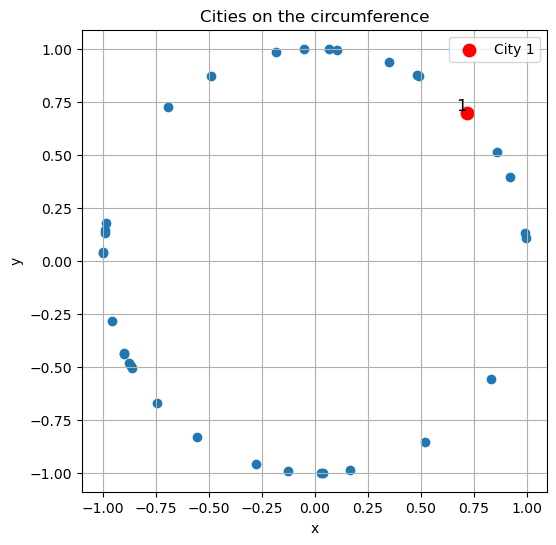

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Columns: city_index, x, y
data = np.loadtxt("Exercise_9.1/cities_circle.txt")

city_index = data[:, 0].astype(int)
x = data[:, 1]
y = data[:, 2]

idx_1 = np.where(city_index == 1)[0][0]

plt.figure(figsize=(6, 6))
plt.scatter(x, y)
plt.scatter(x[idx_1], y[idx_1], color="red", s=80, label="City 1")

plt.text(
    x[idx_1],
    y[idx_1],
    "1",
    fontsize=12,
    color="black",
    ha="right",
    va="bottom"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Cities on the circumference")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

### Best path evolution on the circumference

The plot reports both the best path length and the average path length over the best half of the population. The red dashed line is $2\pi$, which is the continuous circumference length. The optimal route through discrete points is expected to be slightly shorter, because it connects the cities with straight segments, not with circular arcs.

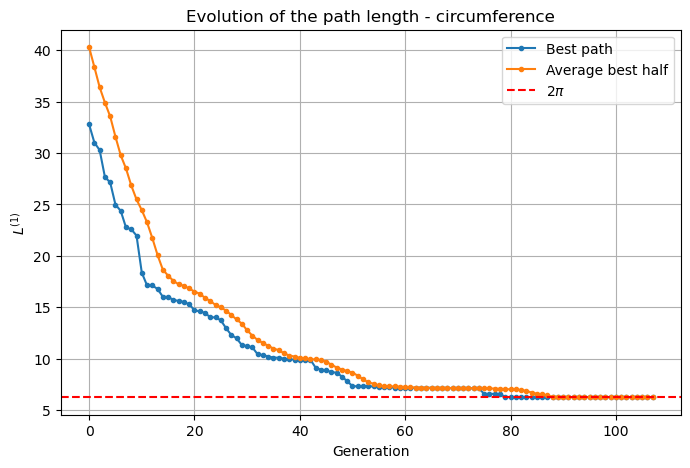

Initial best length: 32.78690
Final best length:   6.24306
Final average over the best half: 6.24306
Last generation stored: 107


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Columns: generation, best_loss, average_best_half
data = np.loadtxt("Exercise_9.1/losses.dat")

generation = data[:, 0]
best_loss = data[:, 1]
average_best_half = data[:, 2]

plt.figure(figsize=(8, 5))
plt.plot(generation, best_loss, marker="o", markersize=3, label="Best path")
plt.plot(generation, average_best_half, marker="o", markersize=3, label="Average best half")

plt.xlabel("Generation")
plt.ylabel(r"$L^{(1)}$")
plt.axhline(y=2*np.pi, color="red", linestyle="--", label=r"$2\pi$")
plt.title("Evolution of the path length - circumference")
plt.grid(True)
plt.legend()
plt.show()

print(f"Initial best length: {best_loss[0]:.5f}")
print(f"Final best length:   {best_loss[-1]:.5f}")
print(f"Final average over the best half: {average_best_half[-1]:.5f}")
print(f"Last generation stored: {int(generation[-1])}")

At first sight, the full-scale plot may suggest that the early-stopping condition could already be satisfied around generation $60$, where the curves look almost flat. However, the criterion used in the code is not based on the visual appearance of the plot. It compares the current values with those measured $10$ generations before, and both monitored quantities must remain within the chosen tolerances.

In particular, the tolerance on the best path is very strict,

$$
\Delta L^{(1)}_\mathrm{best} \leq 10^{-5},
$$

while the average over the best half is allowed to fluctuate slightly more,

$$
\Delta \langle L^{(1)} \rangle_\mathrm{best\ half} \leq 2\times 10^{-2}.
$$

A zoom on the late part of the evolution makes it clearer that, around generation $60$, the population is still improving and the early-stopping condition is not yet satisfied.

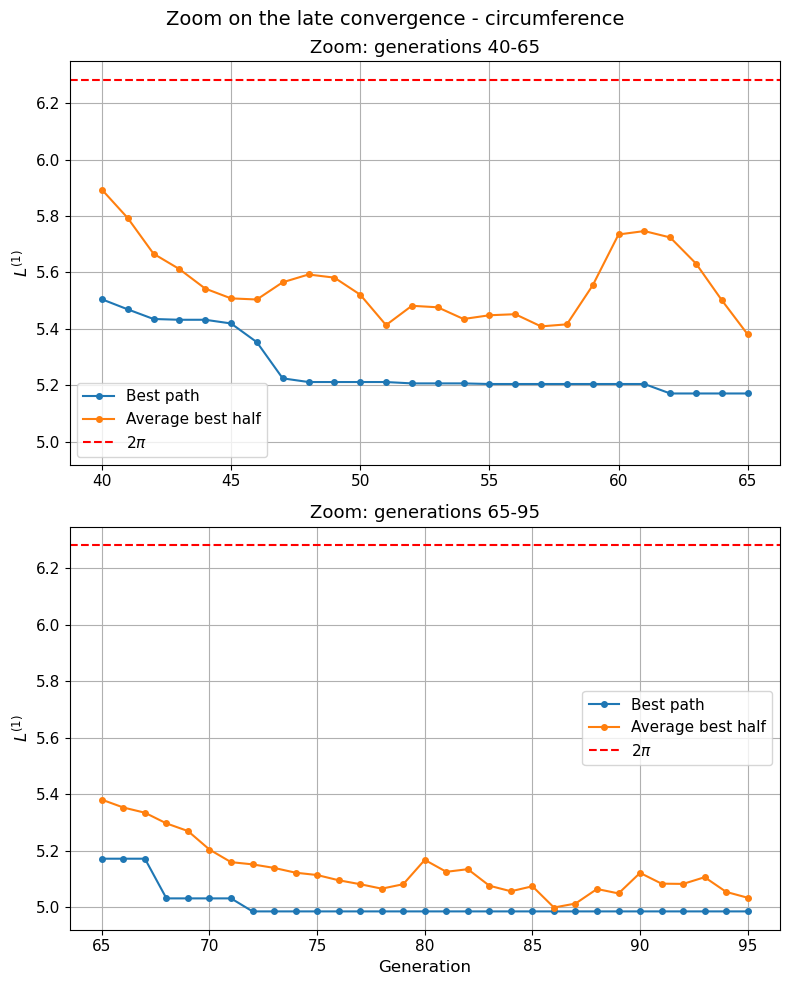

In [11]:
# Zoom on the late convergence for the circumference case

fig, axes = plt.subplots(2, 1, figsize=(8, 10), sharey=True)

# First zoom: generations 40-65
mask_1 = (generation >= 40) & (generation <= 65)

axes[0].plot(generation[mask_1], best_loss[mask_1], marker="o", markersize=4, label="Best path")
axes[0].plot(generation[mask_1], average_best_half[mask_1], marker="o", markersize=4, label="Average best half")
axes[0].axhline(y=2*np.pi, color="red", linestyle="--", label=r"$2\pi$")

axes[0].set_title("Zoom: generations 40-65", fontsize=13)
axes[0].set_ylabel(r"$L^{(1)}$", fontsize=12)
axes[0].tick_params(axis="both", labelsize=11)
axes[0].grid(True)
axes[0].legend(fontsize=11)

# Second zoom: generations 65-95
mask_2 = (generation >= 65) & (generation <= 95)

axes[1].plot(generation[mask_2], best_loss[mask_2], marker="o", markersize=4, label="Best path")
axes[1].plot(generation[mask_2], average_best_half[mask_2], marker="o", markersize=4, label="Average best half")
axes[1].axhline(y=2*np.pi, color="red", linestyle="--", label=r"$2\pi$")

axes[1].set_title("Zoom: generations 65-95", fontsize=13)
axes[1].set_xlabel("Generation", fontsize=12)
axes[1].set_ylabel(r"$L^{(1)}$", fontsize=12)
axes[1].tick_params(axis="both", labelsize=11)
axes[1].grid(True)
axes[1].legend(fontsize=11)

plt.suptitle("Zoom on the late convergence - circumference", fontsize=14)
plt.tight_layout()
plt.show()

#### Comment


The best path length decreases from about $32.79$ to about $6.24306$. The average over the best half of the population reaches almost the same value, meaning that at the end of this run the best half of the population has essentially collapsed onto the same optimal circular ordering.

The zoomed plots show why the early-stopping condition is not satisfied earlier: although the full-scale plot already looks almost flat around generation $60$, small improvements are still visible, especially in the average over the best half. The run stops at generation $107$, when both monitored quantities satisfy the early-stopping condition.

The final value is slightly below $2\pi\simeq 6.28318$, consistently with the fact that the route connects the cities with straight segments. For points on a circle, the expected optimal ordering is the angular ordering along the circumference, up to the two equivalent clockwise and anticlockwise directions.

### Best path on the circumference

Best path length found by the genetic algorithm: 6.24306


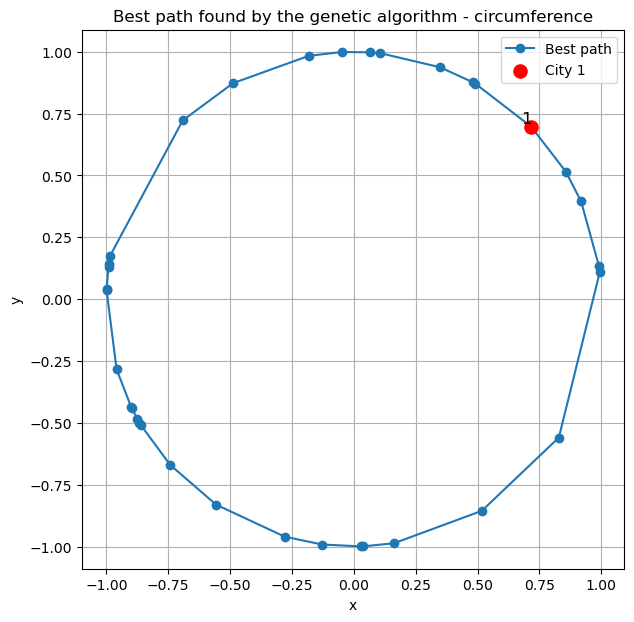

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Coordinates: city_index, x, y
cities = np.loadtxt("Exercise_9.1/cities_circle.txt")
city_index = cities[:, 0].astype(int)
x = cities[:, 1]
y = cities[:, 2]

# Final best path: one city per row, with city 1 repeated at the end
best_path = np.loadtxt("Exercise_9.1/best_path_final.txt").astype(int)

path_x = np.array([x[city_id - 1] for city_id in best_path])
path_y = np.array([y[city_id - 1] for city_id in best_path])

path_length = np.sum(np.sqrt(np.diff(path_x)**2 + np.diff(path_y)**2))
print(f"Best path length found by the genetic algorithm: {path_length:.5f}")

idx_1 = np.where(city_index == 1)[0][0]

plt.figure(figsize=(7, 7))
plt.plot(path_x, path_y, marker="o", linewidth=1.5, label="Best path")
plt.scatter(x[idx_1], y[idx_1], color="red", s=90, zorder=3, label="City 1")

plt.text(
    x[idx_1],
    y[idx_1],
    "1",
    fontsize=12,
    color="black",
    ha="right",
    va="bottom"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Best path found by the genetic algorithm - circumference")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

#### Comment


The final path goes around the circumference without crossings. This is the expected result for the circular TSP: the cities are visited in angular order, and crossing segments would only make the route longer.

### Cities randomly placed inside a square

The second test uses 34 cities uniformly placed inside a square of side 1. In this case the optimal path is less geometrically constrained than in the circular case, so the genetic algorithm must search a less obvious ordering.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


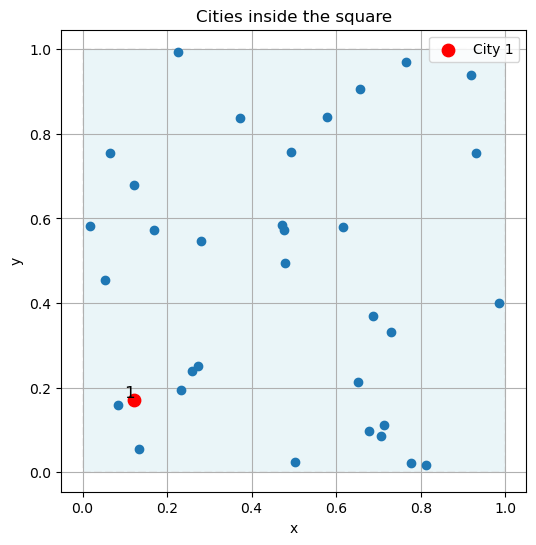

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Columns: city_index, x, y
data = np.loadtxt("Exercise_9.2/cities_square.txt")

city_index = data[:, 0].astype(int)
x = data[:, 1]
y = data[:, 2]

idx_1 = np.where(city_index == 1)[0][0]

plt.figure(figsize=(6, 6))
ax = plt.gca()

square = Rectangle(
    (0, 0),
    1,
    1,
    facecolor="lightblue",
    edgecolor="lightgray",
    linestyle="--",
    linewidth=1.5,
    alpha=0.25,
    zorder=0
)
ax.add_patch(square)

plt.scatter(x, y, zorder=2)
plt.scatter(x[idx_1], y[idx_1], color="red", s=80, label="City 1", zorder=3)

plt.text(
    x[idx_1],
    y[idx_1],
    "1",
    fontsize=12,
    color="black",
    ha="right",
    va="bottom",
    zorder=4
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Cities inside the square")
plt.axis("equal")
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.show()

### Best path evolution inside the square

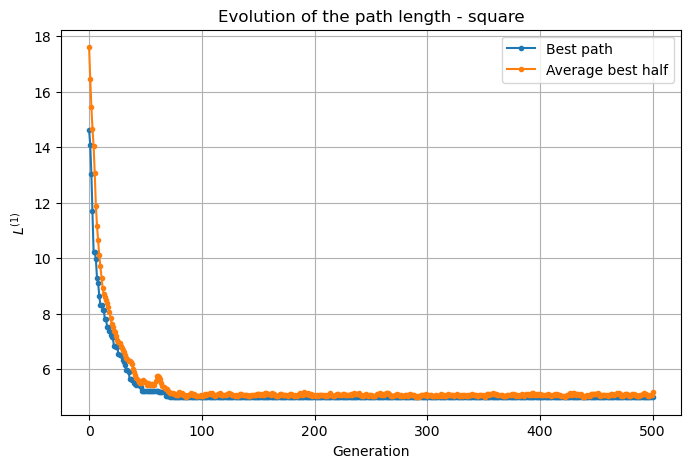

Initial best length: 14.61900
Final best length:   4.98426
Final average over the best half: 5.16796
Last generation stored: 500


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Columns: generation, best_loss, average_best_half
data = np.loadtxt("Exercise_9.2/losses.dat")

generation = data[:, 0]
best_loss = data[:, 1]
average_best_half = data[:, 2]

plt.figure(figsize=(8, 5))
plt.plot(generation, best_loss, marker="o", markersize=3, label="Best path")
plt.plot(generation, average_best_half, marker="o", markersize=3, label="Average best half")

plt.xlabel("Generation")
plt.ylabel(r"$L^{(1)}$")
plt.title("Evolution of the path length - square")
plt.grid(True)
plt.legend()
plt.show()

print(f"Initial best length: {best_loss[0]:.5f}")
print(f"Final best length:   {best_loss[-1]:.5f}")
print(f"Final average over the best half: {average_best_half[-1]:.5f}")
print(f"Last generation stored: {int(generation[-1])}")

#### Comment


The best length decreases from about $14.62$ to about $4.98426$. The average over the best half also decreases, but it remains slightly larger than the best path length. This is reasonable: the population has improved strongly, but the best half has not completely collapsed onto a single route.

For this square case the early-stopping condition was not used. A fixed number of 500 generations was chosen instead, because the stabilization of the single best individual alone is not a robust proof that the population has fully stabilized.

Since the genetic algorithm is stochastic and does not guarantee convergence to the global optimum, the final result should be interpreted as the best route found in this run, not as a formal proof of the absolute minimum.

### Best path inside the square

Best path length found by the genetic algorithm: 4.98426


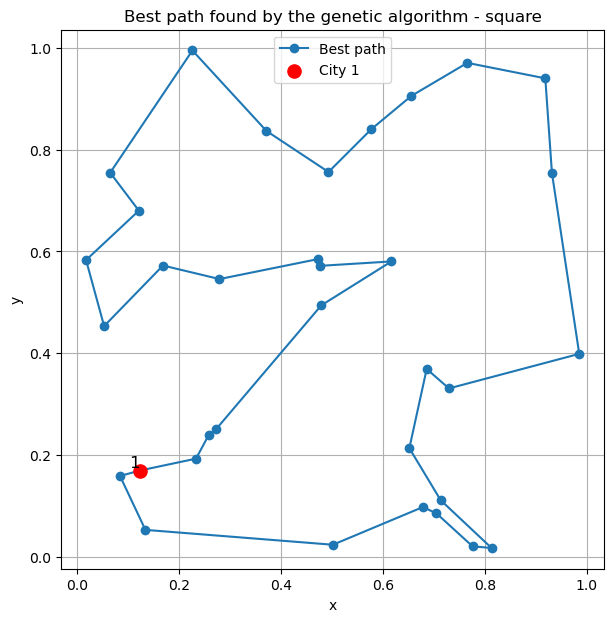

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Coordinates: city_index, x, y
cities = np.loadtxt("Exercise_9.2/cities_square.txt")
city_index = cities[:, 0].astype(int)
x = cities[:, 1]
y = cities[:, 2]

# Final best path: one city per row, with city 1 repeated at the end
best_path = np.loadtxt("Exercise_9.2/best_path_final.txt").astype(int)

path_x = np.array([x[city_id - 1] for city_id in best_path])
path_y = np.array([y[city_id - 1] for city_id in best_path])

path_length = np.sum(np.sqrt(np.diff(path_x)**2 + np.diff(path_y)**2))
print(f"Best path length found by the genetic algorithm: {path_length:.5f}")

idx_1 = np.where(city_index == 1)[0][0]

plt.figure(figsize=(7, 7))
plt.plot(path_x, path_y, marker="o", linewidth=1.5, label="Best path")
plt.scatter(x[idx_1], y[idx_1], color="red", s=90, zorder=3, label="City 1")

plt.text(
    x[idx_1],
    y[idx_1],
    "1",
    fontsize=12,
    color="black",
    ha="right",
    va="bottom"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Best path found by the genetic algorithm - square")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

#### Comment


The final route does not show evident crossings. This is the qualitative structure expected for a good TSP route.